<a href="https://colab.research.google.com/github/deepa905/bank-customer-churn-analysis/blob/main/Bank_Customer_Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bank Customer Churn Analysis
## Business Problem
A bank wants to understand why customers are leaving and identify
high-risk segments to reduce churn and improve retention.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')
%matplotlib inline

In [ ]:
df = pd.read_csv('/content/Churn_Modelling.csv')
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Step 1: Data Understanding

In [ ]:
# Basic information
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nBasic Statistics:")
df.describe()

Shape: (10000, 14)

Column Names:
 ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Data Types:
 RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Basic Statistics:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
# Check for missing values
print("Missing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
 RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicate Rows: 0


## Step 2: Data Cleaning

In [ ]:
# Drop irrelevant columns
df = df.drop(['RowNumber', 'Surname'], axis=1)

# Create readable churn label
df['ChurnLabel'] = df['Exited'].map({1: 'Churned', 0: 'Retained'})

# Create age groups
df['AgeGroup'] = pd.cut(df['Age'],
                         bins=[18, 30, 45, 60, 100],
                         labels=['18-30', '31-45', '46-60', '60+'])

print("Cleaning complete. New shape:", df.shape)
df.head()


Cleaning complete. New shape: (10000, 14)


,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,ChurnLabel,AgeGroup
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Churned,31-45
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Retained,31-45
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Churned,31-45
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Retained,31-45
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Retained,31-45


## Step 3: Exploratory Data Analysis (EDA)
### Business Question 1: What is the overall churn rate?

Overall Churn Rate: 20.37%


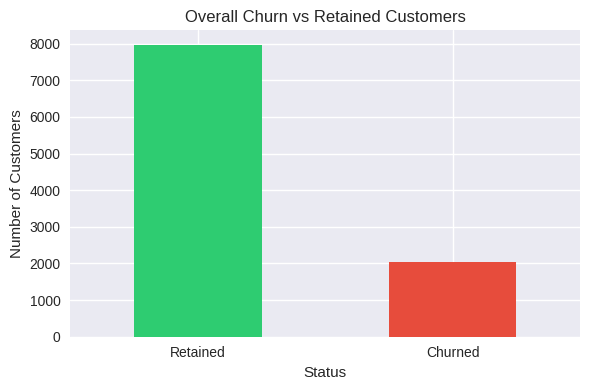

In [ ]:
import os

churn_rate = df['Exited'].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")

# Visualisation
plt.figure(figsize=(6, 4))
df['ChurnLabel'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Overall Churn vs Retained Customers')
plt.xlabel('Status')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()

# Create the directory if it doesn't exist
os.makedirs('../outputs/', exist_ok=True)
plt.savefig('../outputs/01_overall_churn.png')
plt.show()

### Business Question 2: Which geography has the highest churn rate?

  Geography  Churn Rate %
1   Germany     32.443204
2     Spain     16.673395
0    France     16.154767


/tmp/ipykernel_1090/3741176496.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=geo_churn, x='Geography', y='Churn Rate %',


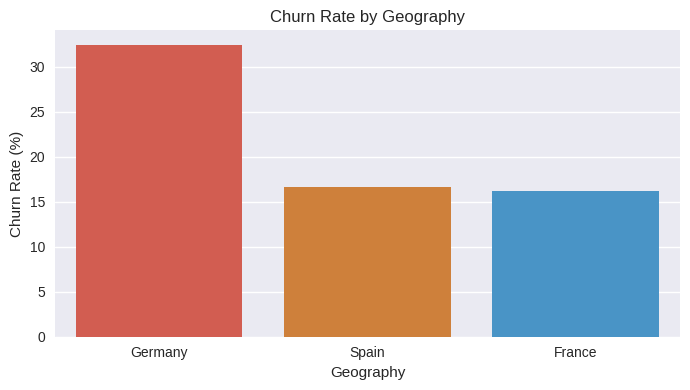

In [ ]:
geo_churn = df.groupby('Geography')['Exited'].mean() * 100
geo_churn = geo_churn.reset_index()
geo_churn.columns = ['Geography', 'Churn Rate %']
geo_churn = geo_churn.sort_values('Churn Rate %', ascending=False)
print(geo_churn)

plt.figure(figsize=(7, 4))
sns.barplot(data=geo_churn, x='Geography', y='Churn Rate %',
            palette=['#e74c3c', '#e67e22', '#3498db'])
plt.title('Churn Rate by Geography')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('../outputs/02_churn_by_geography.png')
plt.show()

### Business Question 3: Do female customers churn more than male customers?

   Gender  Churn Rate %
0  Female     25.071539
1    Male     16.455928


/tmp/ipykernel_1090/1796844006.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gender_churn, x='Gender', y='Churn Rate %',


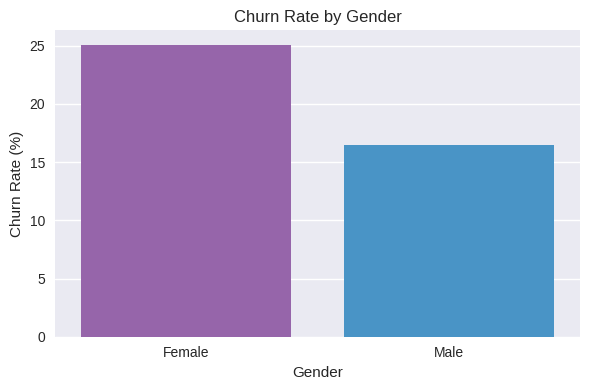

In [ ]:
gender_churn = df.groupby('Gender')['Exited'].mean() * 100
gender_churn = gender_churn.reset_index()
gender_churn.columns = ['Gender', 'Churn Rate %']
print(gender_churn)

plt.figure(figsize=(6, 4))
sns.barplot(data=gender_churn, x='Gender', y='Churn Rate %',
            palette=['#9b59b6', '#3498db'])
plt.title('Churn Rate by Gender')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('../outputs/03_churn_by_gender.png')
plt.show()

### Business Question 4: Which age group churns the most?

/tmp/ipykernel_1090/4034998480.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age_churn, x='Age Group', y='Churn Rate %',


  Age Group  Churn Rate %
0     18-30      7.502569
1     31-45     15.740584
2     46-60     51.123254
3       60+     24.784483


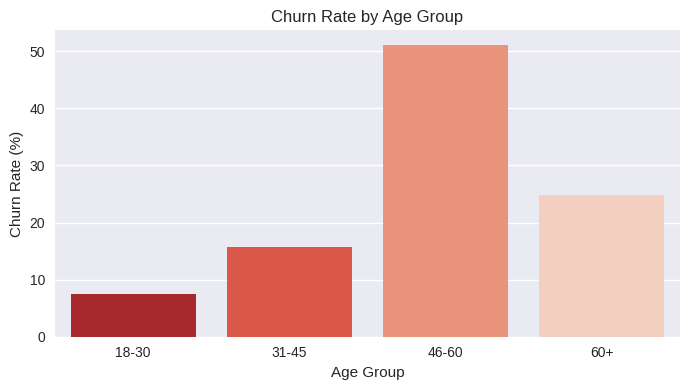

In [ ]:
age_churn = df.groupby('AgeGroup', observed=True)['Exited'].mean() * 100
age_churn = age_churn.reset_index()
age_churn.columns = ['Age Group', 'Churn Rate %']
print(age_churn)

plt.figure(figsize=(7, 4))
sns.barplot(data=age_churn, x='Age Group', y='Churn Rate %',
            palette='Reds_r')
plt.title('Churn Rate by Age Group')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('../outputs/04_churn_by_age_group.png')
plt.show()

### Business Question 5: Do customers with more products churn more?

   Num of Products  Churn Rate %
0                1     27.714398
1                2      7.581699
2                3     82.706767
3                4    100.000000


/tmp/ipykernel_1090/2265185355.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_churn, x='Num of Products', y='Churn Rate %',


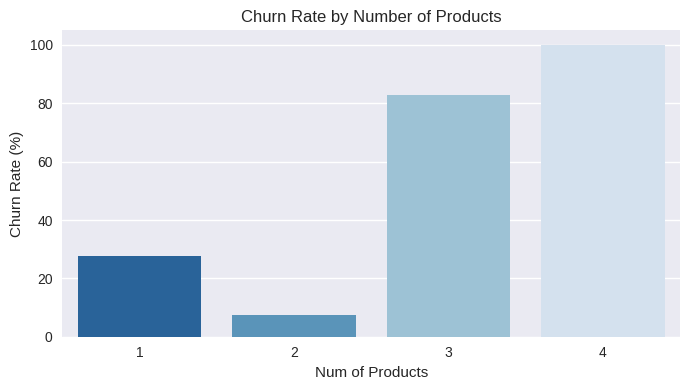

In [ ]:
product_churn = df.groupby('NumOfProducts')['Exited'].mean() * 100
product_churn = product_churn.reset_index()
product_churn.columns = ['Num of Products', 'Churn Rate %']
print(product_churn)

plt.figure(figsize=(7, 4))
sns.barplot(data=product_churn, x='Num of Products', y='Churn Rate %',
            palette='Blues_r')
plt.title('Churn Rate by Number of Products')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('../outputs/05_churn_by_products.png')
plt.show()

### Business Question 6: Does account balance affect churn?

Average Balance by Churn Status:
ChurnLabel
Churned     91108.539337
Retained    72745.296779
Name: Balance, dtype: float64


/tmp/ipykernel_1090/1412065049.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ChurnLabel', y='Balance',


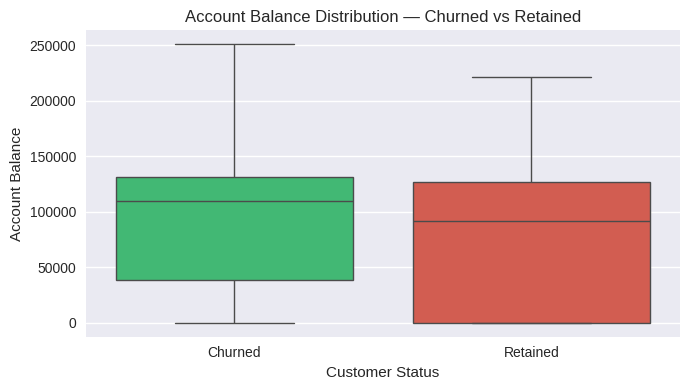

In [ ]:
balance_stats = df.groupby('ChurnLabel')['Balance'].mean()
print("Average Balance by Churn Status:")
print(balance_stats)

plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='ChurnLabel', y='Balance',
            palette=['#2ecc71', '#e74c3c'])
plt.title('Account Balance Distribution — Churned vs Retained')
plt.xlabel('Customer Status')
plt.ylabel('Account Balance')
plt.tight_layout()
plt.savefig('../outputs/06_balance_vs_churn.png')
plt.show()

### Business Question 7: Are inactive members more likely to churn?

  Member Status  Churn Rate %
0      Inactive     26.850897
1        Active     14.269074


/tmp/ipykernel_1090/3212055819.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=active_churn, x='Member Status', y='Churn Rate %',


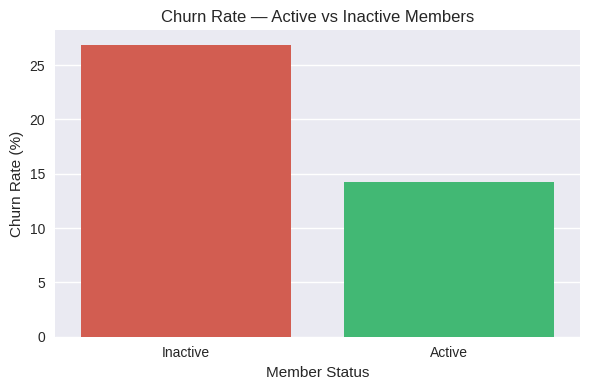

In [ ]:
active_churn = df.groupby('IsActiveMember')['Exited'].mean() * 100
active_churn = active_churn.reset_index()
active_churn['IsActiveMember'] = active_churn['IsActiveMember'].map({
    1: 'Active', 0: 'Inactive'})
active_churn.columns = ['Member Status', 'Churn Rate %']
print(active_churn)

plt.figure(figsize=(6, 4))
sns.barplot(data=active_churn, x='Member Status', y='Churn Rate %',
            palette=['#e74c3c', '#2ecc71'])
plt.title('Churn Rate — Active vs Inactive Members')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('../outputs/07_churn_active_vs_inactive.png')
plt.show()

### Business Question 8: Correlation Heatmap

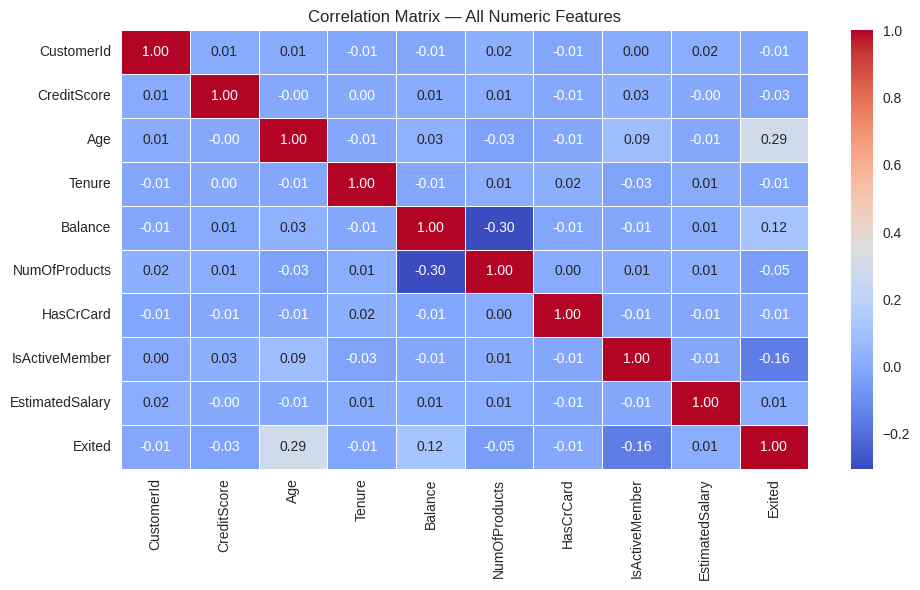

In [ ]:
plt.figure(figsize=(10, 6))
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation = df[numeric_cols].corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5)
plt.title('Correlation Matrix — All Numeric Features')
plt.tight_layout()
plt.savefig('../outputs/08_correlation_heatmap.png')
plt.show()

## Key Findings Summary

Based on the exploratory data analysis, the following insights were identified:

1. **Overall churn rate is 20.37%** — 1 in 5 customers is leaving the bank.
2. **Germany is the highest risk geography** with a churn rate of 32.44%,
   nearly double France (16.15%) and Spain (16.67%).
3. **Female customers churn more** (25.07%) compared to male customers (16.46%).
4. **Age group 46–60 is the highest risk segment** with a 51.12% churn rate —
   more than half of customers in this group are leaving.
5. **Customers with 3–4 products churn at alarming rates** (82.71% and 100%) —
   having more products does NOT improve retention.
6. **Churned customers have higher average balances** ($91,108 vs $72,745) —
   high value customers are leaving at a disproportionate rate.
7. **Inactive members are nearly twice as likely to churn** (26.85% vs 14.27%) —
   engagement is a critical retention factor.
8. **Age is the strongest predictor of churn** (correlation: 0.29), followed by
   active membership status (-0.16).

### Business Recommendations
- **Priority 1:** Launch targeted retention campaigns for German customers
  aged 46–60 with 3+ products
- **Priority 2:** Re-engagement programmes for inactive members —
  this is the most actionable lever
- **Priority 3:** Investigate why high-balance customers are churning —
  potential service quality or competitor offering issue

In [ ]:
import os

# Create the directory if it doesn't exist
os.makedirs('../data', exist_ok=True)

# Save cleaned dataset for SQL import
df.to_csv('../data/churn_cleaned.csv', index=False)
print("Cleaned dataset saved successfully.")
print(f"Final shape: {df.shape}")
print(f"\nColumns available for SQL analysis:\n{df.columns.tolist()}")

Cleaned dataset saved successfully.
Final shape: (10000, 14)

Columns available for SQL analysis:
['CustomerId', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'ChurnLabel', 'AgeGroup']


In [ ]:
df.to_csv('churn_cleaned.csv', index=False)
from google.colab import files
files.download('churn_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>